# Credit Card Fraud Detection

## Business Problem

Credit card fraud costs issuers and customers significant money every year, 
and the challenge is asymmetric: missing a fraudulent transaction (false 
negative) means direct financial loss, while flagging a legitimate transaction 
as fraud (false positive) creates customer friction and erodes trust. This 
project builds a model to catch fraudulent transactions while minimizing 
unnecessary friction for legitimate cardholders.


## Dataset Description

The dataset contains ~285,000 European cardholder transactions from September 
2013, with only 492 labeled as fraud — a severe class imbalance (~0.17%). 
Most features (V1–V28) are anonymized via PCA for privacy; `Amount` and `Time` 
remain in their original form and will be used for business-relevant analysis.

In [14]:
!pip install phik -q
!pip install lightgbm -q
!pip install optuna-integration -q


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
#library imports 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap 
import phik
import lightgbm as lgb
from sklearn.model_selection import (train_test_split, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from optuna_integration import OptunaSearchCV
from optuna.distributions import IntDistribution, FloatDistribution
from sklearn.metrics import average_precision_score, f1_score, confusion_matrix
import warnings 
warnings.filterwarnings("ignore")

## Exploratory Data Analysis

## Data Overview

In [16]:
#saving the file into a dataframe
df = pd.read_csv('creditcard.csv')

In [17]:
#displaying the first 5 lines of the dataframe and showing the info section
display(df.head(5))
df.info()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

**Summary:** The dataset contains 284,807 non-null entries and 31 columns: 
`V1`–`V28` are anonymized features obtained via PCA transformation, while 
`Time` (seconds elapsed since the first transaction) and `Amount`(transaction amount) remain in their original, untransformed form. `Class` is the target 
variable (0 = legitimate, 1 = fraud).

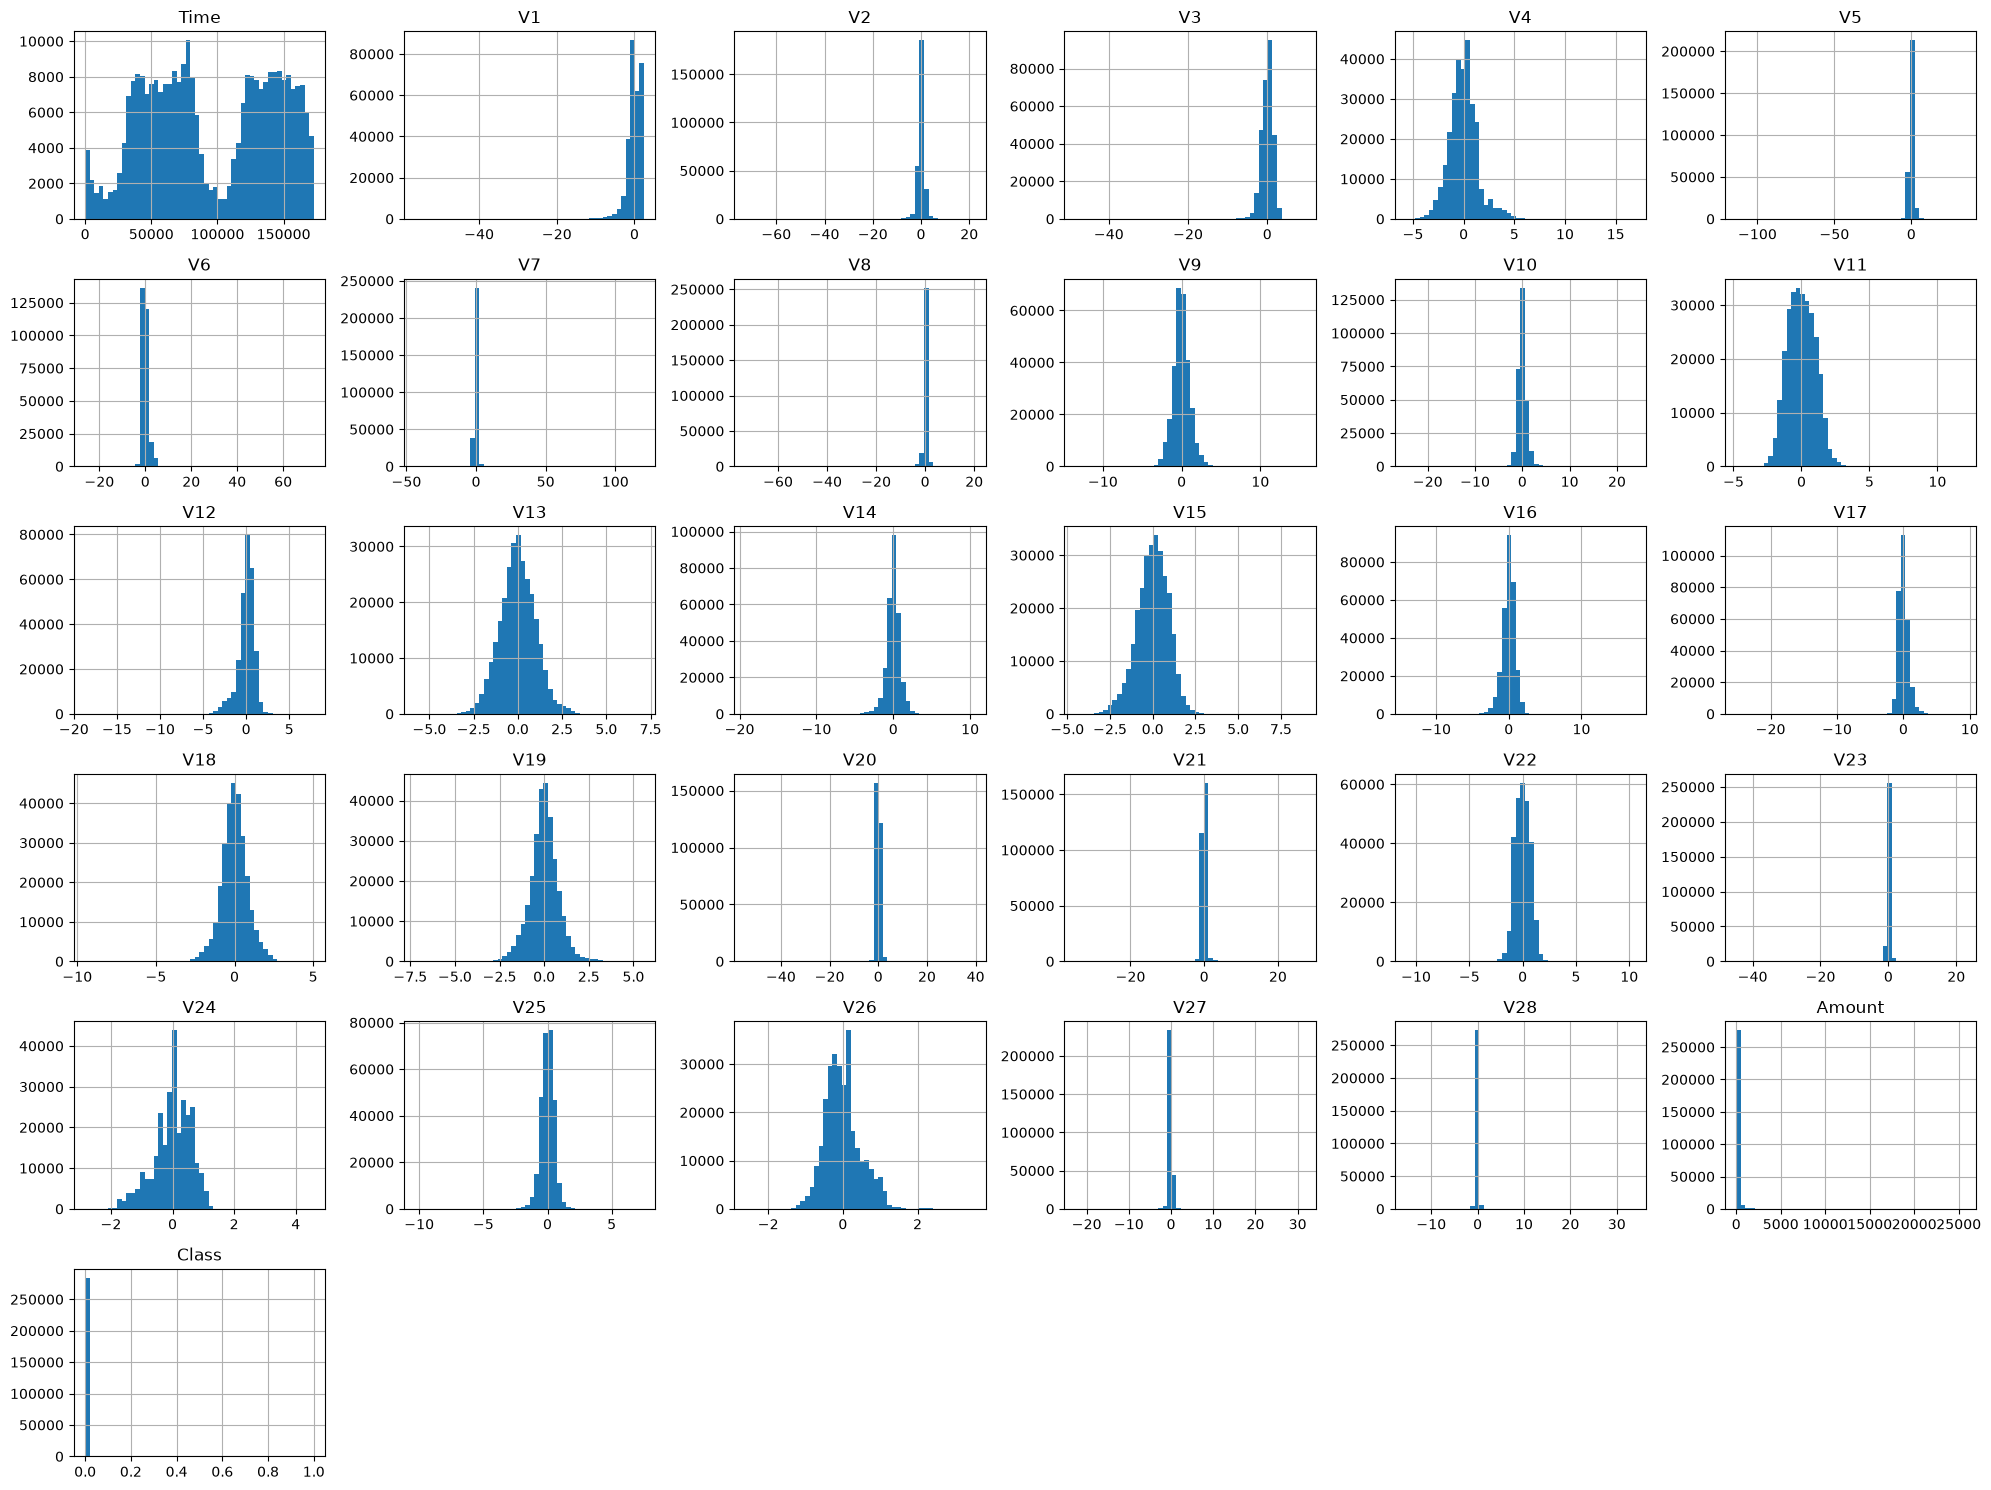

In [18]:
#distribution of all features across the dataset
df.hist(figsize=(20, 15), bins=50)
plt.tight_layout()
plt.show()

**Summary:**
- `Time` shows a bimodal distribution with 2 visible peaks, suggesting 
transactions are concentrated in two time periods (likely day/night activity patterns).
- `V1`–`V28` are approximately normally distributed and centered near 0, 
as expected after PCA transformation.
- `Amount` is heavily right-skewed, with most transactions being small 
amounts and a long tail extending to ~25,000. This confirms the need for 
scaling in the preprocessing step.
- `Class` is nearly invisible at 1 due to the severe class imbalance 
(0.17% fraud), confirming that accuracy will be a misleading metric.

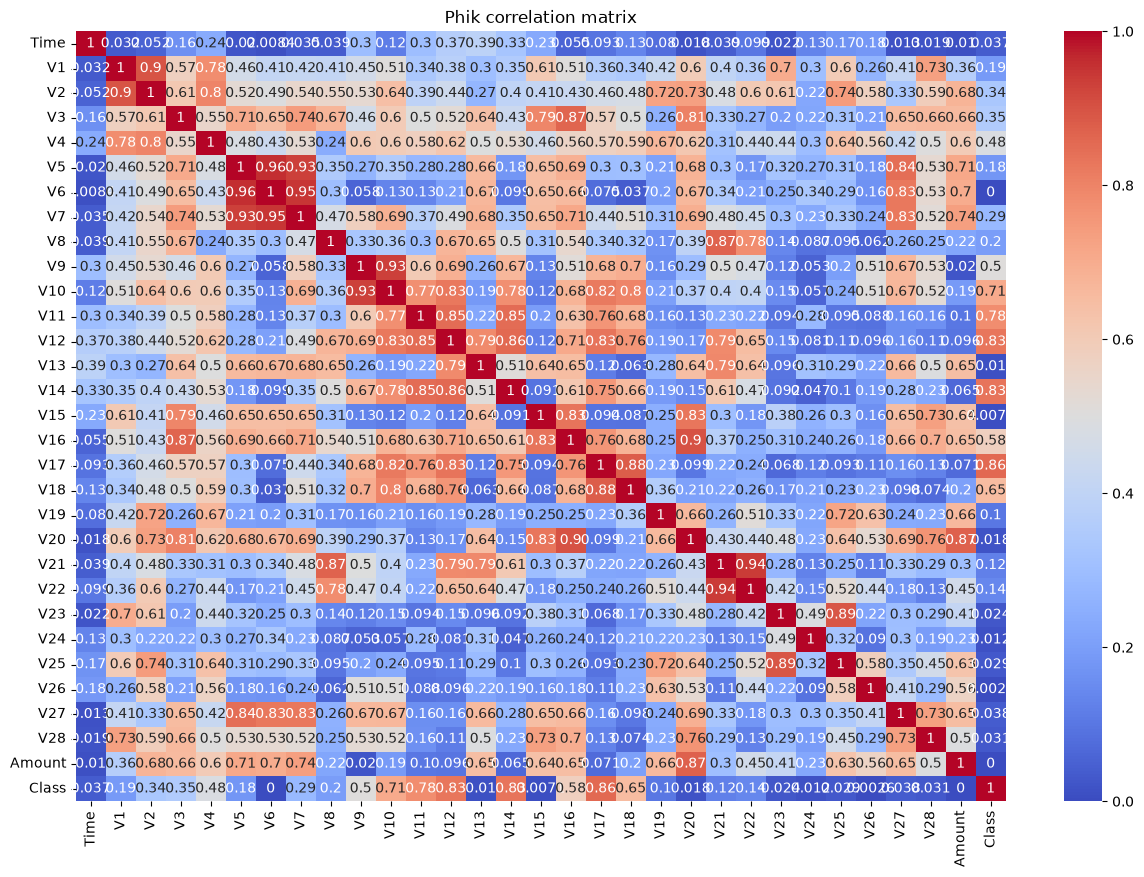

In [19]:
#correlation matrix
plt.figure(figsize=(15, 10))
interval_cols = [col for col in df.columns if col != 'Class']
corr_matrix = df.phik_matrix(interval_cols=interval_cols)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Phik correlation matrix')
plt.show()

**Summary:** The phik correlation matrix reveals that V10–V12, V14, V17, 
and V18 show the strongest association with `Class` (φk ≈ 0.65–0.86), 
suggesting these components carry the most signal for fraud detection. 
`Time` and `Amount` show weak correlation with the target.

In [20]:
#creating RANDOM_STATE
RANDOM_STATE = 42

#dividing the dataset into features and target
X = df.drop('Class', axis=1)
y = df['Class']

#dividing the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

#checking the shape of the resulting splits
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

#preprocessor step
preprocessor = ColumnTransformer(
    [
        ('scaler', RobustScaler(), ['Amount', 'Time'])
    ], remainder='passthrough'
)

#pipeline step
pipe = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', lgb.LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE, verbose=-1))
    ]
)

#hyperparameter tuning
optuna_param = {
    'model__num_leaves': IntDistribution(20, 300),
    'model__learning_rate': FloatDistribution(0.01, 0.3),
    'model__n_estimators': IntDistribution(100, 1000),
    'model__min_child_samples': IntDistribution(10, 100),
}

#performing OptunaSearch
search = OptunaSearchCV(
    pipe,
    optuna_param,
    n_trials=20,
    timeout=600,
    scoring='average_precision',
    cv=5,
    random_state=RANDOM_STATE
)

search.fit(X_train, y_train)

[I 2026-07-13 19:57:47,828] A new study created in memory with name: no-name-0dcae1db-3e2e-43c9-b0d3-ba776a537bbb


(213605, 30) (71202, 30) (213605,) (71202,)


[I 2026-07-13 19:58:15,306] Trial 0 finished with value: 0.8517528580872806 and parameters: {'model__num_leaves': 147, 'model__learning_rate': 0.2514632893713383, 'model__n_estimators': 162, 'model__min_child_samples': 39}. Best is trial 0 with value: 0.8517528580872806.
[I 2026-07-13 19:59:05,592] Trial 1 finished with value: 0.8512669397207894 and parameters: {'model__num_leaves': 156, 'model__learning_rate': 0.0964958730958879, 'model__n_estimators': 291, 'model__min_child_samples': 25}. Best is trial 0 with value: 0.8517528580872806.
[I 2026-07-13 19:59:57,862] Trial 2 finished with value: 0.8557623252857821 and parameters: {'model__num_leaves': 69, 'model__learning_rate': 0.10237812053436175, 'model__n_estimators': 414, 'model__min_child_samples': 100}. Best is trial 2 with value: 0.8557623252857821.
[I 2026-07-13 20:01:04,562] Trial 3 finished with value: 0.8557293858630164 and parameters: {'model__num_leaves': 162, 'model__learning_rate': 0.0787472520910885, 'model__n_estimators

,estimator,Pipeline(step...verbose=-1))])
,param_distributions,"{'model__learning_rate': FloatDistribu...01, step=None), 'model__min_child_samples': IntDistributi...ow=10, step=1), 'model__n_estimators': IntDistributi...w=100, step=1), 'model__num_leaves': IntDistributi...ow=20, step=1)}"
,cv,5
,n_jobs,1
,n_trials,20
,random_state,42
,scoring,'average_precision'
,timeout,600
,enable_pruning,False
,error_score,nan
,max_iter,1000


In [21]:
#hyperparameter tuning results
print("Best PR-AUC:", search.best_score_)
print("Best params:", search.best_params_)

Best PR-AUC: 0.8598119278280288
Best params: {'model__num_leaves': 221, 'model__learning_rate': 0.1747910525809852, 'model__n_estimators': 733, 'model__min_child_samples': 78}


In [22]:
#model training using the hyperparameter tuning results
best_param = search.best_params_

best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMClassifier(**{k.replace('model__', ''): v for k, v in best_param.items()},
                                 class_weight='balanced',
                                 random_state=RANDOM_STATE,
                                 verbose=-1
                                 ))
])

best_pipe.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specifie

In [23]:
#model predictions on test set 
y_pred = best_pipe.predict(X_test)
y_pred_proba = best_pipe.predict_proba(X_test)[:, 1]

#model evaluation metrics
print(f"PR-AUC: {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"f1_score: {f1_score(y_test, y_pred)}")

PR-AUC: 0.8846
f1_score: 0.8504672897196262


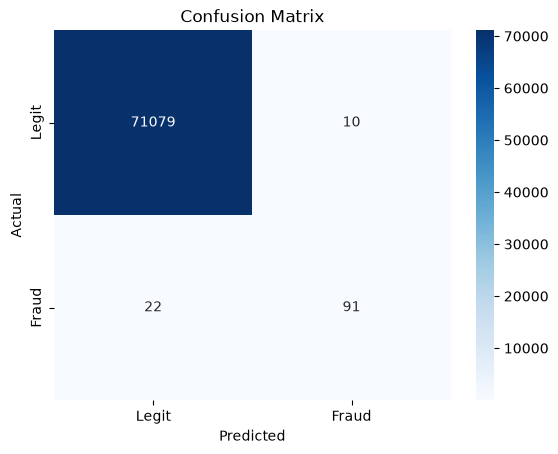

In [24]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Summary:** LGBMClassifier was chosen for fraud detection due to its efficiency on large tabular datasets and built-in support for class imbalance via `class_weight='balanced'`. Hyperparameter tuning was performed using OptunaSearchCV (n_trials=20, cv=5,scoring='average_precision'), achieving a best cross-validated PR-AUC of 0.86. On the held-out test set, the final model achieved PR-AUC = 0.88 and F1 = 0.85. Confusion matrix analysis revealed that 91 fraudulent transactions were correctly identified, while 22 were missed — at the cost of incorrectly flagging only 10 legitimate transactions.

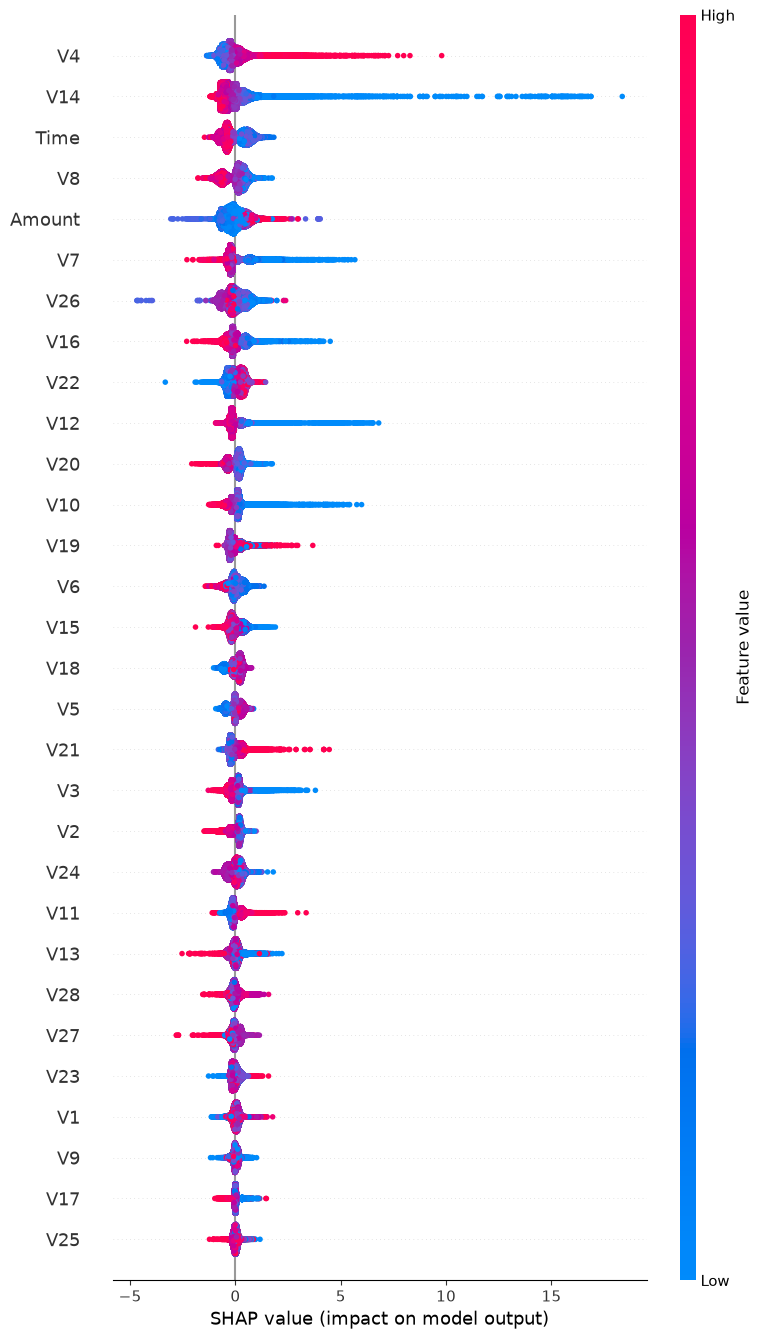

In [25]:
#Extracting preprocessor and model from the pipeline
preprocessor_fitted = best_pipe.named_steps['preprocessor']
X_test_transformed = preprocessor_fitted.transform(X_test)
model = best_pipe.named_steps['model']

#SHAP analysis using TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

#Cleaning feature names after ColumnTransformer transformation
feature_names = preprocessor_fitted.get_feature_names_out()
clean_names = [name.replace('scaler__', '').replace('remainder__', '') 
               for name in feature_names]

#SHAP summary plot - feature importance visualization
shap.summary_plot(shap_values, X_test_transformed, feature_names=clean_names, max_display=30)

**Summary:** SHAP analysis identifies V4 and V14 as the most influential features in fraud detection. High values of V4 strongly increase the probability of fraud, while low values of V14 are a consistent fraud signal — both features show clear directional patterns. V8, Amount, and Time also contribute meaningfully: notably, Amount and Time are the only non-anonymized features in the dataset, suggesting that transaction size and timing carry detectable fraud patterns despite not being the primary predictors. The majority of features (V1–V28) show SHAP values clustered near zero, confirming that predictive signal is concentrated in a small subset of PCA components. 

## Project Summary

This project builds a fraud detection model on the ULB Credit Card Fraud 
dataset — 284,807 real European cardholder transactions from September 2013, 
of which only 492 (0.17%) are fraudulent.

**Data:** The dataset contains 31 features: V1–V28 are anonymized via PCA, 
while `Time` and `Amount` remain in their original form. EDA revealed no 
missing values, a heavily right-skewed `Amount` distribution (confirming 
the need for RobustScaler), and a bimodal `Time` distribution suggesting 
day/night transaction patterns. The severe class imbalance (0.17% fraud) 
ruled out accuracy as a reliable metric — PR-AUC was chosen instead.

**Correlations:** Phik correlation analysis identified V10–V12, V14, V17, 
and V18 as the features most associated with fraud (φk ≈ 0.65–0.86), 
while `Time` and `Amount` showed weak correlation with the target.

**Modeling:** LGBMClassifier was selected for its efficiency on large 
tabular datasets and native class imbalance support via 
`class_weight='balanced'`. Hyperparameter tuning via OptunaSearchCV 
(n_trials=20, cv=5, scoring='average_precision') achieved a 
cross-validated PR-AUC of 0.86. On the held-out test set, the final 
model achieved **PR-AUC = 0.88** and **F1 = 0.85** — placing it in 
the top range of published results on this benchmark dataset.

**Evaluation:** Confusion matrix analysis showed 91 fraudulent transactions 
correctly identified and only 22 missed, while incorrectly flagging just 
10 legitimate transactions — a strong precision/recall balance that 
minimizes both financial loss and customer friction.

**Interpretability:** SHAP analysis confirmed that V4 and V14 are the 
dominant fraud indicators: high V4 values and low V14 values are 
consistently associated with fraud. Amount and Time — the only 
non-anonymized features — also contribute meaningfully, suggesting 
that transaction size and timing carry detectable fraud signals. 
Predictive power is concentrated in a small subset of PCA components, 
with most V-features showing near-zero SHAP values.

## Business Recommendations

**1. Deploy the model as a real-time transaction screening layer**
The model achieves PR-AUC = 0.88 with only 10 false positives per 71,202 
transactions — a false positive rate of 0.014%. This means the system can 
flag suspicious transactions for review without meaningfully disrupting the 
customer experience, making it suitable for real-time deployment in a 
payments pipeline.

**2. Prioritize reducing False Negatives over False Positives**
The model currently misses 22 fraudulent transactions. Each missed fraud 
represents a direct financial loss — both the transaction amount and the 
operational cost of dispute resolution. Lowering the classification 
threshold from 0.5 to 0.3 would increase Recall at the cost of slightly 
more false positives, which is an acceptable tradeoff when the cost of 
missed fraud exceeds the cost of a blocked legitimate transaction.

**3. Use SHAP-based monitoring in production**
V4 and V14 are the dominant fraud signals. Monitoring the distribution of 
these features in production over time would allow early detection of 
concept drift — if fraudsters adapt their behavior, shifts in V4/V14 
distributions would be the first detectable signal, enabling proactive 
model retraining before performance degrades.

**4. Investigate Time and Amount patterns further**
Despite being the only non-anonymized features, Time and Amount rank 
among the top 5 SHAP contributors. This suggests that transaction timing 
(the bimodal day/night pattern identified in EDA) and transaction size 
are exploitable signals — worth engineering additional features around 
in a production system (e.g. rolling average spend per customer, 
transactions per hour).

**5. Establish a cost-sensitive decision threshold**
The optimal classification threshold should be determined by the actual 
cost ratio between a missed fraud and a false positive block. For a 
payments company like Revolut, where customer experience is a key 
differentiator, this ratio should be explicitly quantified and used to 
set the threshold — rather than defaulting to 0.5.